In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pynwb import NWBHDF5IO

In [2]:
# version = 'version 0.251010.2006'
version = 'version 0.251008.1146'
dirpath = '/Users/kimchm/Documents/KimNiNature2024/' + version
animal = '/sub-BAYLORJH035/'
sess = 'sub-BAYLORJH035_ses-FOV3-2022-01-12_ophys.nwb'
filepath = dirpath + animal + sess

In [3]:
io = NWBHDF5IO(filepath, mode="r")
nwbfile = io.read()
nwbfile

Data type,uint8
Shape,"(0, 0, 0)"
Array size,0.00 bytes
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),0
Compressed size (bytes),0
Compression ratio,undefined
Data type,int32
Shape,"(2,)"


In [4]:
trials = nwbfile.intervals['trials'][:]
sum(trials['ErrR'] == False)

223

# Two Photon Series

In [5]:
imgacq = nwbfile.acquisition["TwoPhotonSeries"].data[:]
imgacq


array([], shape=(0, 0, 0), dtype=uint8)

# Image Segmentation

In [6]:
imgseg = nwbfile.processing["ophys"]["ImageSegmentation"]["PlaneSegmentation"]
imgseg

PlaneSegmentation pynwb.ophys.PlaneSegmentation at 0x6401966032
Fields:
  colnames: ['voxel_mask' 'iscell']
  columns: (
    voxel_mask_index <class 'hdmf.common.table.VectorIndex'>,
    voxel_mask <class 'hdmf.common.table.VectorData'>,
    iscell <class 'hdmf.common.table.VectorData'>
  )
  description: suite2p output
  id: id <class 'hdmf.common.table.ElementIdentifiers'>
  imaging_plane: ImagingPlane pynwb.ophys.ImagingPlane at 0x6401961760
Fields:
  conversion: 1.0
  description: standard
  device: devices pynwb.device.Device at 0x6401962240
Fields:
  description:     
  manufacturer: best manufacturer

  excitation_lambda: 600.0
  grid_spacing: <HDF5 dataset "grid_spacing": shape (3,), type "<f8">
  grid_spacing_unit: microns
  imaging_rate: 6.0
  indicator: GCaMP
  location: V1
  optical_channel: (
    OpticalChannel <class 'pynwb.ophys.OpticalChannel'>
  )
  origin_coords_unit: meters
  unit: meters

In [7]:
imgseg_vm = imgseg.voxel_mask[:]
print(imgseg_vm.shape)

(77349,)


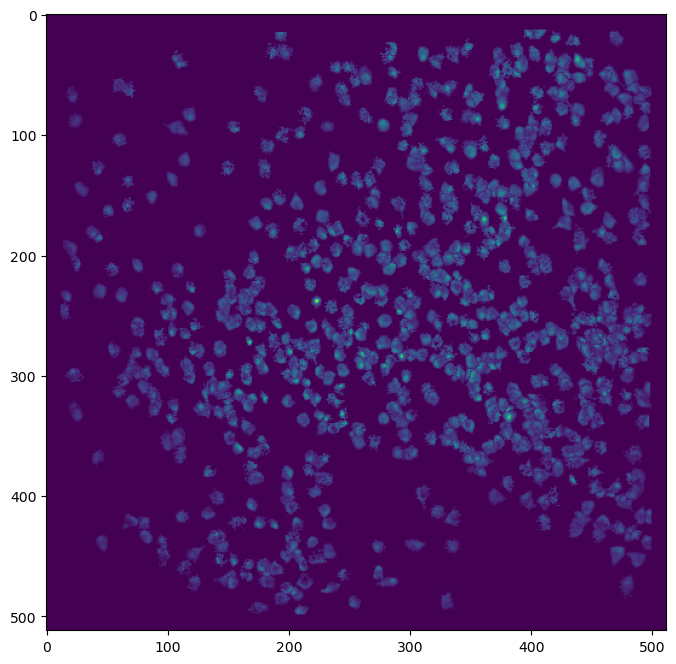

In [8]:
imgseg_col = np.copy(imgseg_vm)
nroi = imgseg_col.shape[0]
fov_imgseg0 = np.zeros((512,512))
for pix in range(nroi):
    x = imgseg_col[pix][0]
    y = imgseg_col[pix][1]
    w = imgseg_col[pix][3]
    fov_imgseg0[y,x] = w
plt.figure(figsize=(8,8))
plt.imshow(fov_imgseg0, aspect='auto')    

# ROIS

In [9]:
rois = nwbfile.processing["ophys"]["Fluorescence"]["ROI Response Series"].rois[:]
# rois = nwbfile.processing["ophys"]["Neuropil"]["ROI Response Series"].rois[:]
rois

,voxel_mask,iscell
id,,
0,"[[440, 268, 0, 3.2251709], [441, 268, 0, 4.583...","[1.0, 0.9414111702602674]"
1,[],"[1.0, 0.9248381802141207]"
2,"[[438, 273, 0, 3.8223443], [439, 273, 0, 9.217...","[1.0, 0.9568540094729738]"
3,[],"[1.0, 0.9105603104211089]"
4,"[[448, 275, 0, 2.0586092], [438, 276, 0, 2.163...","[1.0, 0.9837803852282557]"
...,...,...
803,"[[403, 342, 0, 5.6228247], [404, 342, 0, 5.319...","[1.0, 0.5352937347543153]"
804,[],"[1.0, 0.8484603221038707]"
805,"[[443, 273, 0, 13.32658], [444, 273, 0, 12.217...","[1.0, 0.5281766609651622]"


In [10]:
rois_vm = rois.voxel_mask

In [11]:
nroi = rois_vm.shape[0]
wgt = np.array([],dtype=np.float32)
xcoord = np.array([],dtype=np.float32)
ycoord = np.array([],dtype=np.float32)
fov = np.zeros((nroi,512,512))
for roi in range(nroi):
    roi0 = rois_vm[roi]
    npix = roi0.shape[0]
    for pix in range(npix):
        x = roi0[pix][0]
        y = roi0[pix][1]
        w = roi0[pix][3]
        fov[roi,y,x] = w
        wgt = np.append(wgt,w)
        xcoord = np.append(xcoord,x)
        ycoord = np.append(ycoord,y)
fov_sum = np.sum(fov,axis=0)    

print('number of rois ' + str(nroi))


number of rois 808


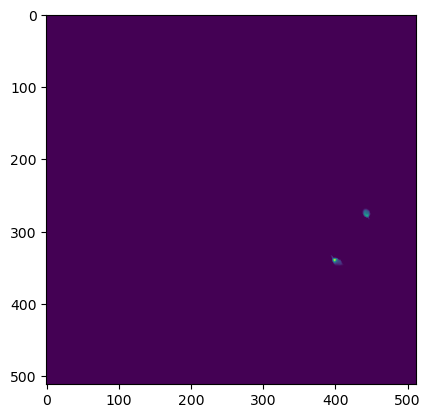

In [12]:
plt.figure()
plt.imshow(fov_sum)    

# ROI Response Series

In [28]:
# load data from HDFView
data = np.loadtxt('/Users/kimchm/Documents/KimNiNature2024/sub-BAYLORJH035_ses-FOV3-2022-01-12_ophys-roi-data.txt')


# # load data with PyNWB
# data = nwbfile.processing["ophys"]["Fluorescence"]["ROI Response Series"].data[:]
# # data = nwbfile.processing["ophys"]["Neuropil"]["ROI Response Series"].data[:]

print('number of ROIs: ' + str(data.shape[1]))
print('number of timesteps: ' + str(data.shape[0]))

number of ROIs: 808
number of timesteps: 13143


Text(0, 0.5, 'ROIs')

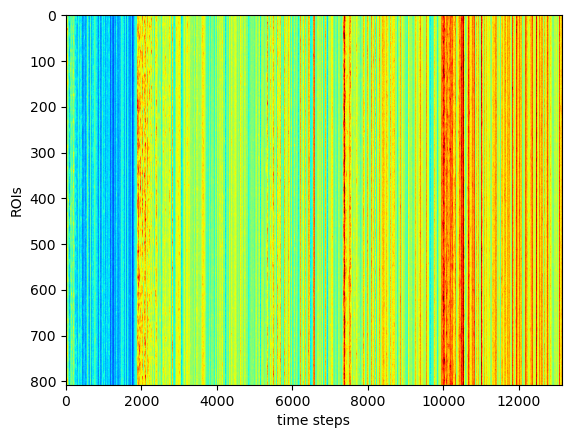

In [29]:
plt.figure()
plt.imshow(np.transpose(data), cmap='jet', aspect='auto', vmin=0, vmax=300)
plt.xlabel('time steps')
plt.ylabel('ROIs')

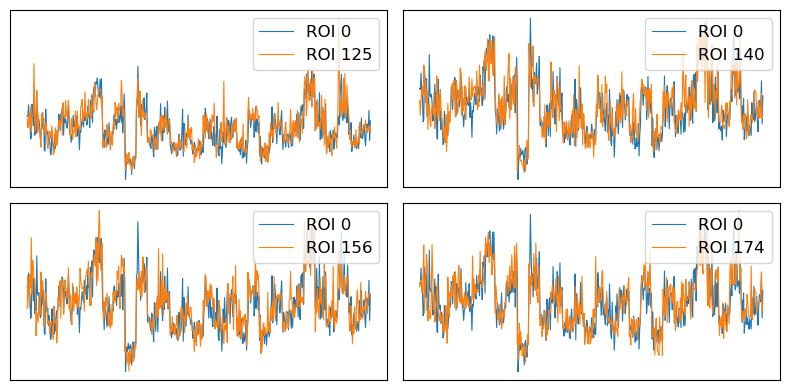

In [33]:
rndcells = np.sort(np.random.permutation(nroi)[:25])
plt.figure(figsize=(8,4))
for i in range(4):
    plt.subplot(2,2,i+1)
    cell = rndcells[i]
    plt.plot(data[-500:,0], lw=0.8, label='ROI 0')
    plt.plot(data[-500:,cell], lw=0.8, label='ROI ' + str(cell))
    plt.legend(fontsize=12, loc=1)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()

In [31]:
data_corr = np.corrcoef(np.transpose(data))
data_corr.shape

(808, 808)

mean correlation:  0.6510888496383769


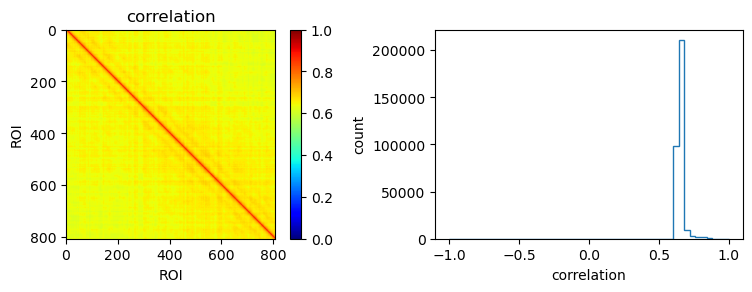

In [34]:
mask = np.triu(np.ones(data_corr.shape), k=1).astype(bool)
plt.figure(figsize=(8,3))
plt.subplot(121)
plt.imshow(data_corr, cmap='jet', vmin=0.0, vmax=1);
plt.colorbar()
plt.xlabel('ROI')
plt.ylabel('ROI')
plt.title('correlation')
plt.subplot(122)
plt.hist(data_corr[mask].flatten(), bins=50, range=(-1,1), histtype='step');
plt.xlabel('correlation')
plt.ylabel('count')
plt.tight_layout()

print('mean correlation: ', np.mean(data_corr[mask]))
